In [1]:
import pandas as pd

df = pd.read_csv("Telco Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Telco Customer Churn.csv")

# Create a copy for EDA
df_eda = df.copy()

# Convert Churn into numeric format for analysis
df_eda["ChurnFlag"] = df_eda["Churn"].map({"No": 0, "Yes": 1})

# Convert TotalCharges into numeric format for EDA only
df_eda["TotalCharges_num"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")

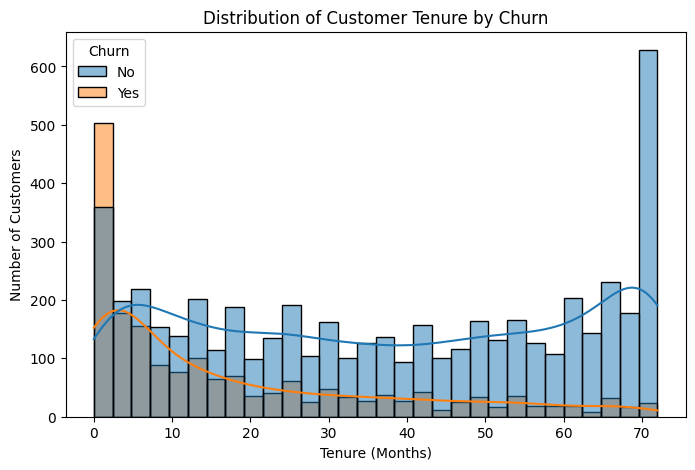

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_eda, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Distribution of Customer Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [7]:
bins = [-1, 12, 24, 48, 72]
labels = ["0-12 months", "13-24 months", "25-48 months", "49-72 months"]

df_eda["TenureGroup"] = pd.cut(df_eda["tenure"], bins=bins, labels=labels)

tenure_churn = df_eda.groupby("TenureGroup")["ChurnFlag"].mean().reset_index()
tenure_churn["ChurnRate (%)"] = tenure_churn["ChurnFlag"] * 100

tenure_churn[["TenureGroup", "ChurnRate (%)"]]

/tmp/ipykernel_15607/3312667841.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df_eda.groupby("TenureGroup")["ChurnFlag"].mean().reset_index()


,TenureGroup,ChurnRate (%)
0,0-12 months,47.438243
1,13-24 months,28.710938
2,25-48 months,20.388959
3,49-72 months,9.513176


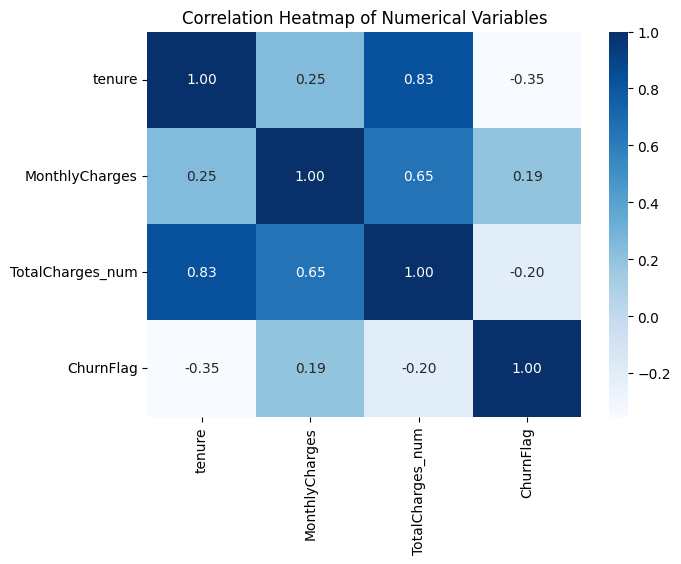

In [5]:
corr_matrix = df_eda[["tenure", "MonthlyCharges", "TotalCharges_num", "ChurnFlag"]].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

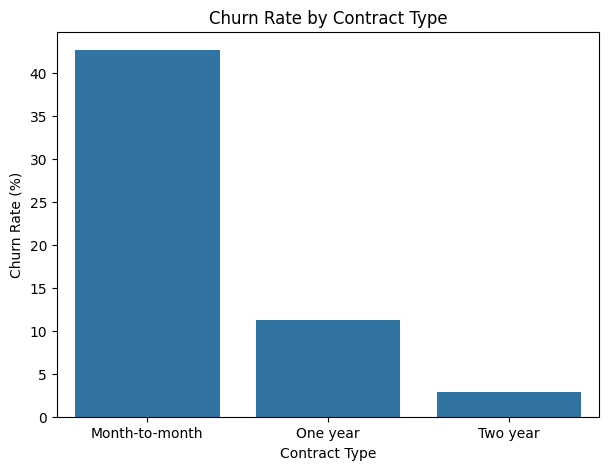

,Contract,ChurnRate (%)
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


In [6]:
contract_churn = df_eda.groupby("Contract")["ChurnFlag"].mean().reset_index()
contract_churn["ChurnRate (%)"] = contract_churn["ChurnFlag"] * 100

plt.figure(figsize=(7,5))
sns.barplot(data=contract_churn, x="Contract", y="ChurnRate (%)")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

contract_churn[["Contract", "ChurnRate (%)"]]

In [7]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
# Check the data type of TotalCharges
df["TotalCharges"].dtype

dtype('O')

In [9]:
# Check blank values in TotalCharges
(df["TotalCharges"].astype(str).str.strip() == "").sum()

np.int64(11)

In [10]:
# Convert TotalCharges to numeric and identify invalid values
df["TotalCharges_num"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges_num"].isnull().sum()

np.int64(11)

In [11]:
df[df["TotalCharges_num"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [12]:
# Check number of unique customer IDs
df["customerID"].nunique()

7043

In [13]:
# Check duplicate customer IDs
df["customerID"].duplicated().sum()

np.int64(0)

In [14]:
# Check churn distribution
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [15]:
# Check churn distribution in percentage
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [16]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Telco Customer Churn.csv")

# Create a copy for modelling
df_model = df.copy()

# Convert TotalCharges from object to numeric
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")

# Handle missing values in TotalCharges
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(0)

# Remove customerID from modelling features
df_model = df_model.drop(columns=["customerID"])

# Convert target variable into binary format
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

In [17]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [18]:
# Create tenure group
bins = [-1, 12, 24, 48, 72]
labels = ["0-12 months", "13-24 months", "25-48 months", "49-72 months"]

df_model["TenureGroup"] = pd.cut(df_model["tenure"], bins=bins, labels=labels)

# Create service count
service_cols = [
    "PhoneService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

df_model["ServiceCount"] = (df_model[service_cols] == "Yes").sum(axis=1)

df_model[["tenure", "TenureGroup", "ServiceCount", "Churn"]].head()

,tenure,TenureGroup,ServiceCount,Churn
0,1,0-12 months,1,0
1,34,25-48 months,3,0
2,2,0-12 months,3,1
3,45,25-48 months,3,0
4,2,0-12 months,1,1


In [19]:
# Separate features and target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Apply one-hot encoding to categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.shape

(7043, 34)

In [20]:
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount"]

scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

X_encoded[num_cols].head().round(3)

,tenure,MonthlyCharges,TotalCharges,ServiceCount
0,-1.277,-1.160,-0.993,-1.053
1,0.066,-0.260,-0.172,0.032
2,-1.237,-0.363,-0.958,0.032
3,0.514,-0.747,-0.194,0.032
4,-1.237,0.197,-0.939,-1.053


In [21]:
from sklearn.model_selection import train_test_split

# Split the encoded dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 34)
Testing set: (1409, 34)


In [22]:
from sklearn.linear_model import LogisticRegression

# Develop baseline model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
baseline_model.fit(X_train, y_train)

# Display model
baseline_model

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# Make predictions
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
roc_auc = roc_auc_score(y_test, y_prob_baseline)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Accuracy: 0.8
Precision: 0.655
Recall: 0.519
F1-score: 0.579
ROC-AUC: 0.842

Confusion Matrix:
[[933 102]
 [180 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [24]:
from sklearn.ensemble import RandomForestClassifier

# Develop improved model using Random Forest
improved_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the improved model
improved_model.fit(X_train, y_train)

# Display model
improved_model

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=5,
                       n_jobs=-1, random_state=42)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# Make predictions using improved model
y_pred_improved = improved_model.predict(X_test)
y_prob_improved = improved_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
improved_accuracy = accuracy_score(y_test, y_pred_improved)
improved_precision = precision_score(y_test, y_pred_improved)
improved_recall = recall_score(y_test, y_pred_improved)
improved_f1 = f1_score(y_test, y_pred_improved)
improved_roc_auc = roc_auc_score(y_test, y_prob_improved)

print("Accuracy:", round(improved_accuracy, 3))
print("Precision:", round(improved_precision, 3))
print("Recall:", round(improved_recall, 3))
print("F1-score:", round(improved_f1, 3))
print("ROC-AUC:", round(improved_roc_auc, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_improved))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

Accuracy: 0.754
Precision: 0.525
Recall: 0.791
F1-score: 0.631
ROC-AUC: 0.845

Confusion Matrix:
[[767 268]
 [ 78 296]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [26]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Telco Customer Churn.csv")

# Apply the same preparation steps used before modelling
df_validated = df.copy()

# Convert TotalCharges into numeric format
df_validated["TotalCharges"] = pd.to_numeric(df_validated["TotalCharges"], errors="coerce")

# Handle missing values in TotalCharges
df_validated["TotalCharges"] = df_validated["TotalCharges"].fillna(0)

# Convert Churn into binary format
df_validated["Churn"] = df_validated["Churn"].map({"No": 0, "Yes": 1})

# Automated validation checks
validation_results = {}

# Check 1: Missing values
validation_results["Missing Values"] = df_validated.isnull().sum().sum() == 0

# Check 2: Duplicate records based on customerID
validation_results["Duplicate Customer IDs"] = df_validated["customerID"].duplicated().sum() == 0

# Check 3: TotalCharges data type
validation_results["TotalCharges Numeric"] = pd.api.types.is_numeric_dtype(df_validated["TotalCharges"])

# Check 4: Valid churn values
validation_results["Valid Churn Values"] = set(df_validated["Churn"].unique()).issubset({0, 1})

# Display validation results
for check, result in validation_results.items():
    status = "PASSED" if result else "FAILED"
    print(f"{check}: {status}")

# Final validation decision
if all(validation_results.values()):
    print("\nFinal Result: All validation checks passed. Dataset is ready for modelling.")
else:
    print("\nFinal Result: Some validation checks failed. Dataset requires further cleaning.")

Missing Values: PASSED
Duplicate Customer IDs: PASSED
TotalCharges Numeric: PASSED
Valid Churn Values: PASSED

Final Result: All validation checks passed. Dataset is ready for modelling.
